# EDA - Predicting Smartphone Addiction

[Playground Series S6E8](https://www.kaggle.com/competitions/playground-series-s6e8)

- 과제: `addicted_label` 확률 예측 (이진 분류)
- 평가 지표: ROC AUC
- 데이터: `data/train.csv`, `data/test.csv`, `data/sample_submission.csv` (train 14컬럼 / test 13컬럼, 합성 데이터)
- 마감: 2026-08-31 23:59 UTC

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")
TARGET = "addicted_label"

In [3]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"train: {train.shape}, test: {test.shape}")
train.head()

train: (691369, 14), test: (296302, 13)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## 기본 구조

컬럼 타입, 결측치, 중복 여부를 먼저 확인한다.

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

In [5]:
missing = pd.DataFrame({
    "train_missing": train.isna().sum(),
    "train_missing_pct": train.isna().mean() * 100,
    "test_missing": test.reindex(columns=train.columns).isna().sum(),
})
missing[missing["train_missing"] > 0].sort_values("train_missing", ascending=False)

,train_missing,train_missing_pct,test_missing
social_media_hours,133995,19.381112,47397
gaming_hours,126821,18.343461,59420
weekend_screen_time,112063,16.208855,50697
daily_screen_time_hours,95854,13.864376,32788
app_opens_per_day,80710,11.673940,25705
notifications_per_day,67584,9.775388,34221
stress_level,55148,7.976638,19626
work_study_hours,51518,7.451592,27777
sleep_hours,44480,6.433612,22455
academic_work_impact,44224,6.396584,25721


In [6]:
print(f"train 중복 행: {train.duplicated().sum()}")
print(f"id 유일성: train={train['id'].is_unique}, test={test['id'].is_unique}")

train 중복 행: 0
id 유일성: train=True, test=True


## 타깃 분포

클래스 불균형 정도가 검증 전략과 확률 보정에 영향을 준다.

addicted_label
1    490474
0    200895
Name: count, dtype: int64
양성 비율: 0.7094


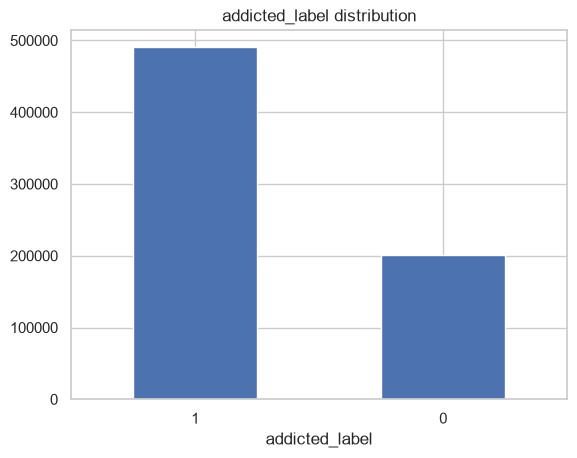

In [7]:
target_counts = train[TARGET].value_counts()
print(target_counts)
print(f"양성 비율: {train[TARGET].mean():.4f}")

target_counts.plot.bar(rot=0, title=f"{TARGET} distribution")
plt.show()

## 수치형 피처

In [8]:
num_cols = train.select_dtypes(include="number").columns.drop(["id", TARGET], errors="ignore").tolist()
cat_cols = train.select_dtypes(exclude="number").columns.tolist()
print(f"수치형 {len(num_cols)}개: {num_cols}")
print(f"범주형 {len(cat_cols)}개: {cat_cols}")

train[num_cols].describe().T

수치형 9개: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
범주형 3개: ['gender', 'stress_level', 'academic_work_impact']


,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


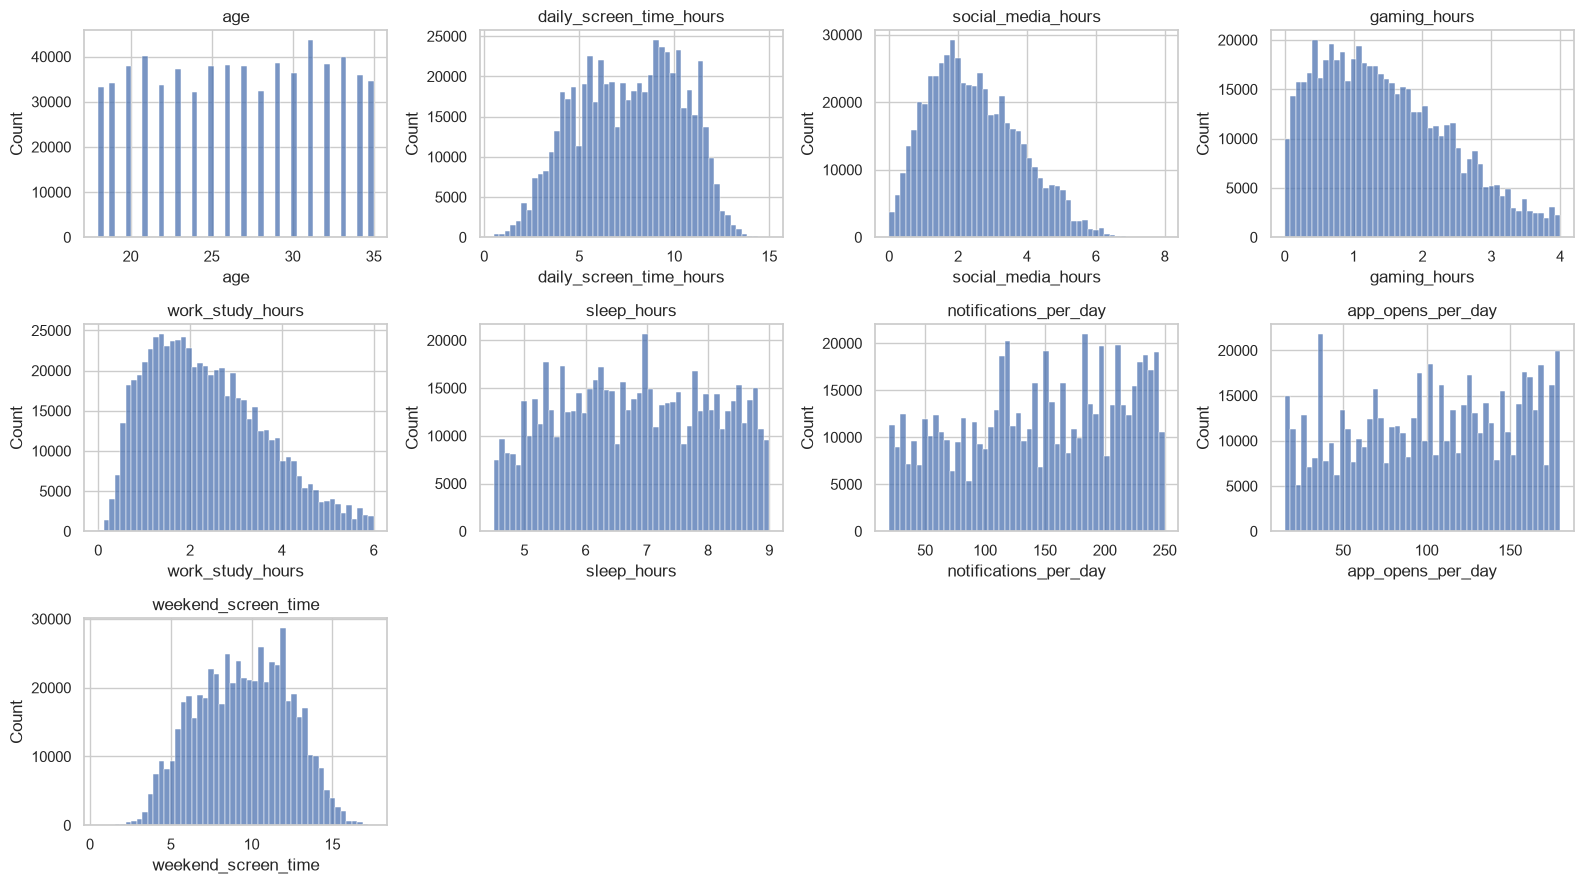

In [9]:
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(train[col], bins=50, ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## 범주형 피처

In [10]:
for col in cat_cols:
    print(f"--- {col} (nunique={train[col].nunique()}) ---")
    print(train[col].value_counts(dropna=False).head(10))
    print()

--- gender (nunique=3) ---
gender
Male      223662
Female    221595
Other     217078
NaN        29034
Name: count, dtype: int64

--- stress_level (nunique=3) ---
stress_level
High      220873
Low       207783
Medium    207565
NaN        55148
Name: count, dtype: int64

--- academic_work_impact (nunique=2) ---
academic_work_impact
Yes    330566
No     316579
NaN     44224
Name: count, dtype: int64



## 타깃과의 관계

notifications_per_day     -0.011583
age                        0.004043
sleep_hours                0.042545
app_opens_per_day          0.063482
gaming_hours               0.205283
work_study_hours           0.251416
social_media_hours         0.532409
weekend_screen_time        0.589903
daily_screen_time_hours    0.611398
Name: addicted_label, dtype: float64


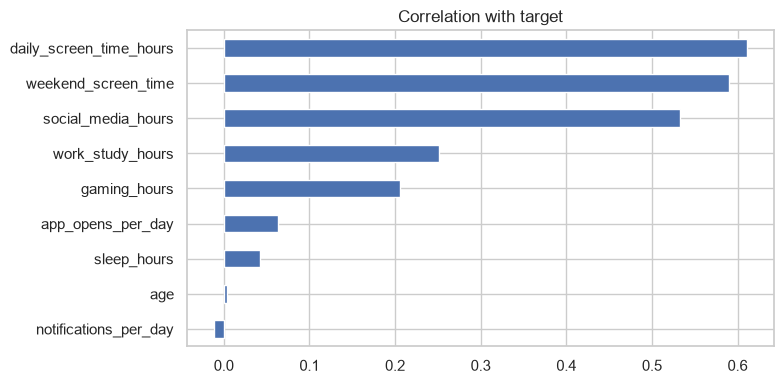

In [11]:
corr_with_target = train[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
corr_with_target.plot.barh(figsize=(8, max(4, 0.3 * len(num_cols))), title="Correlation with target")
print(corr_with_target)
plt.tight_layout()
plt.show()

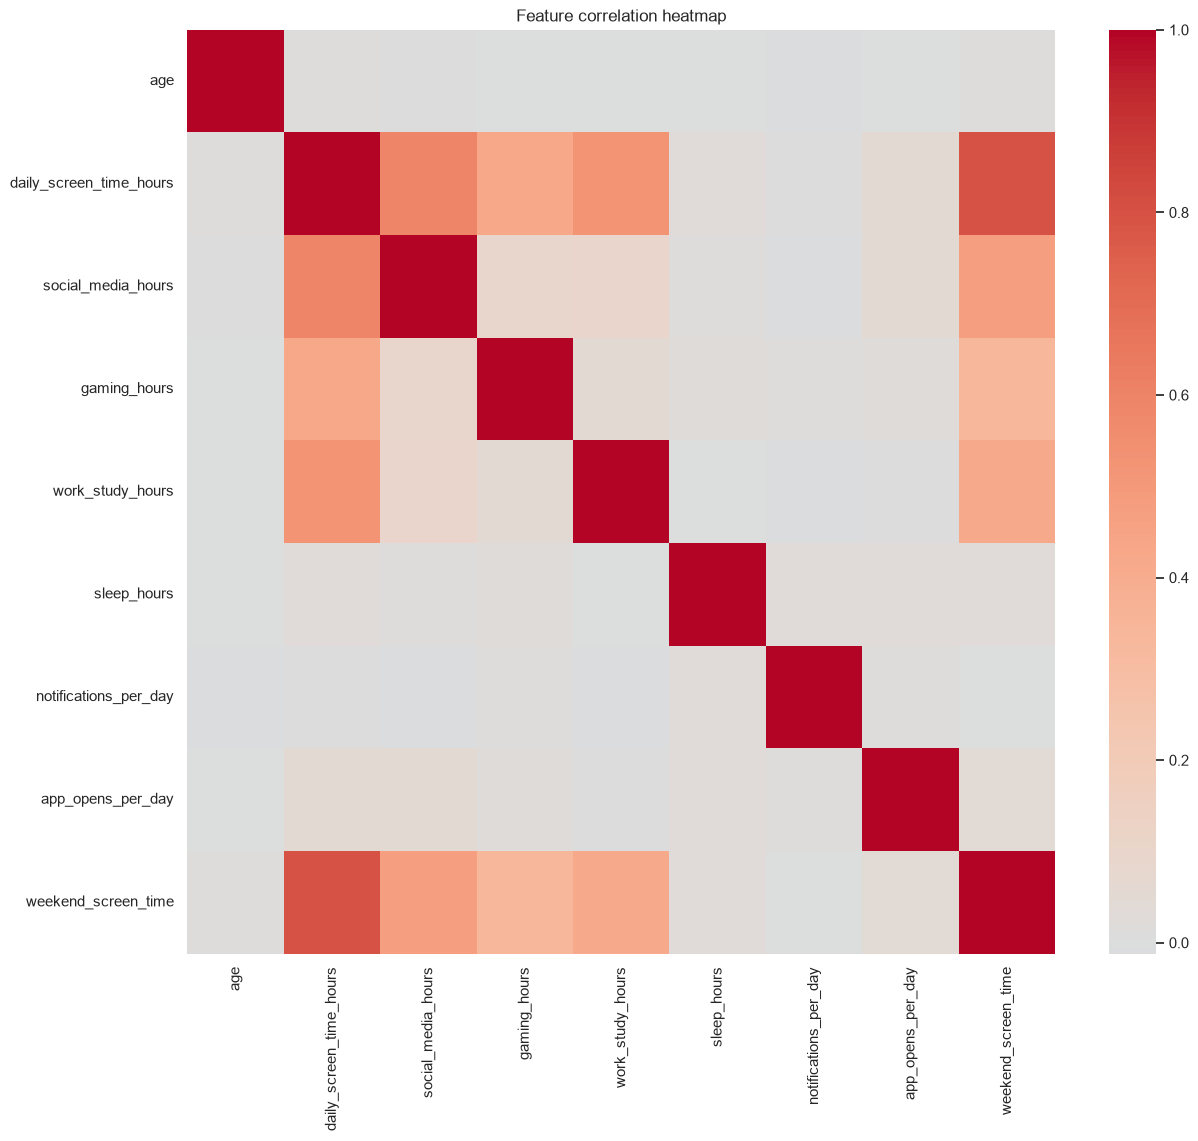

In [12]:
plt.figure(figsize=(14, 12))
sns.heatmap(train[num_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlation heatmap")
plt.show()

## train vs test 분포 비교

합성 데이터라도 train/test 분포가 어긋난 피처가 있으면 검증 설계에 반영해야 한다.

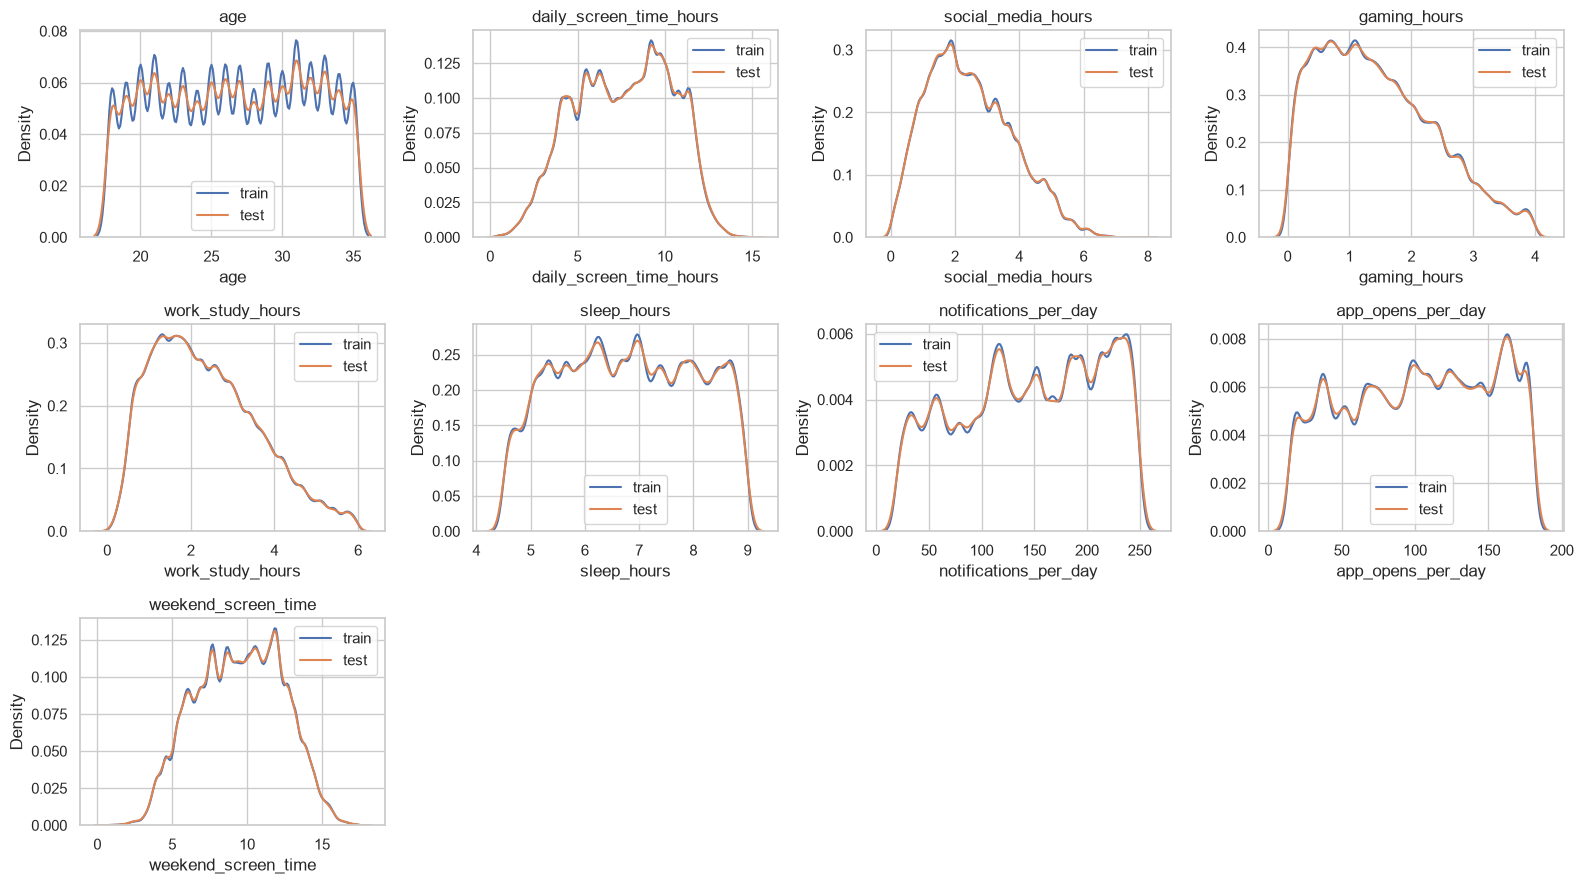

In [13]:
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
for ax, col in zip(axes.flat, num_cols):
    sns.kdeplot(train[col], label="train", ax=ax)
    sns.kdeplot(test[col], label="test", ax=ax)
    ax.set_title(col)
    ax.legend()
for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## 관찰 정리

- (여기에 EDA에서 발견한 사실을 기록한다)
- 다음 단계: 검증 전략 수립, 베이스라인 모델